In [2]:
import sys
print(sys.executable)

c:\Users\13521\Desktop\ChangeDetection\Change_detection\.venv\Scripts\python.exe


In [3]:
import os
import pandas as pd
from pathlib import Path

import cv2 as cv

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [4]:
PROJECT_DIR = Path("../")
LOVEDA_DIR = PROJECT_DIR/"datasets"/"LoveDA"
LEVIR_DIR = PROJECT_DIR/"datasets"/"LEVIR-CD"
print(LOVEDA_DIR)
print(LEVIR_DIR)

..\datasets\LoveDA
..\datasets\LEVIR-CD


In [5]:
print("loveDA EXISTS: ",LOVEDA_DIR.exists())
print("LEVIR-CD EXISTS: ", LEVIR_DIR.exists())

loveDA EXISTS:  True
LEVIR-CD EXISTS:  True


In [6]:
for folder in os.listdir(LOVEDA_DIR):
    print(folder)

Test
Train
Val


In [7]:
Train_path = LOVEDA_DIR/"Train"
for folder in os.listdir(Train_path):
    print(folder)

Rural
Urban


In [8]:
Urban_path = Train_path/"Urban"
for folder in os.listdir(Urban_path):
    print(folder)

images_png
masks_png


In [9]:
image_folder = Urban_path/"images_png"
images = list(image_folder.glob('*.png'))
print(len(images))

1156


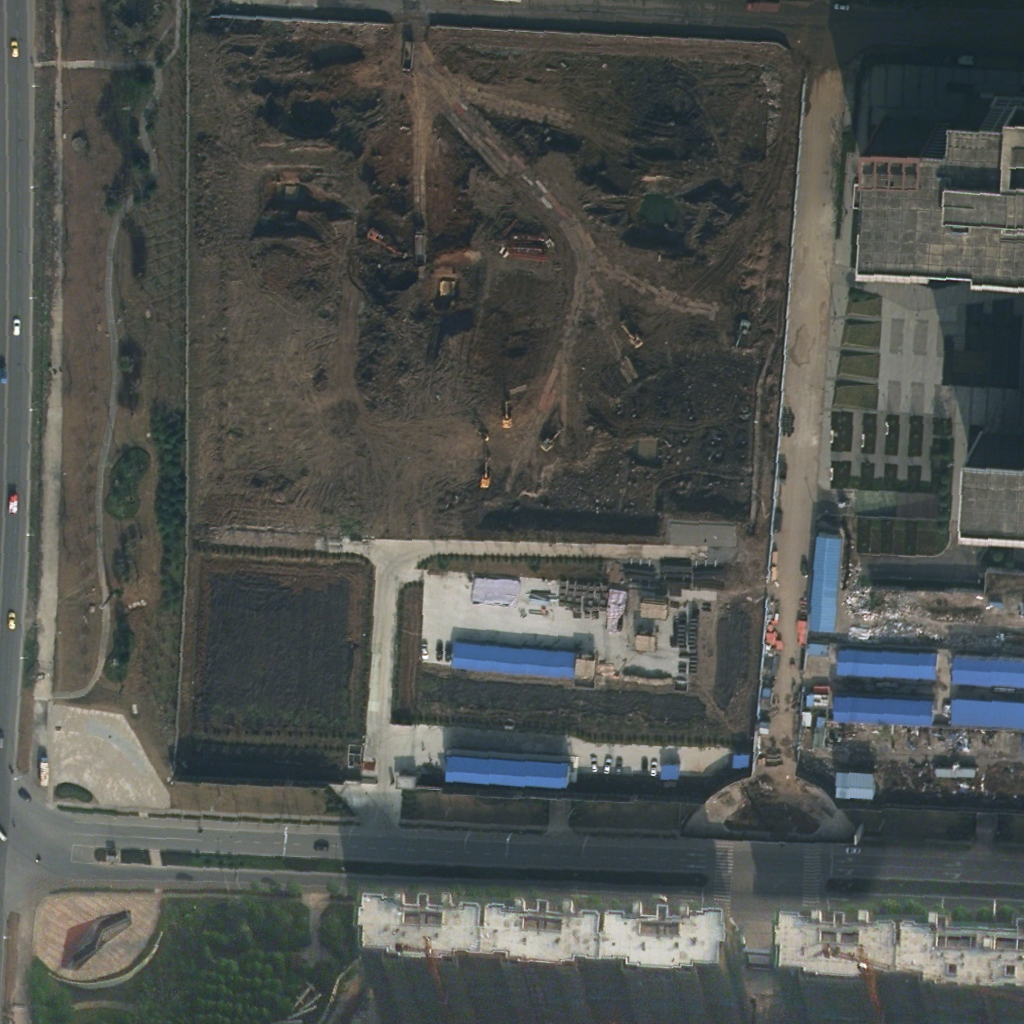

In [10]:
img = Image.open(images[0])
img

In [11]:
img = np.array(img)

print("Shape: ",img.shape)
print("DataType: ",img.dtype)
print("minimum: ",img.min())
print("Maximum: ",img.max())

Shape:  (1024, 1024, 3)
DataType:  uint8
minimum:  8
Maximum:  255


In [12]:
masked_folder = Urban_path/"masks_png"
masks = list(masked_folder.glob('*.png'))
print(len(masks))

1156


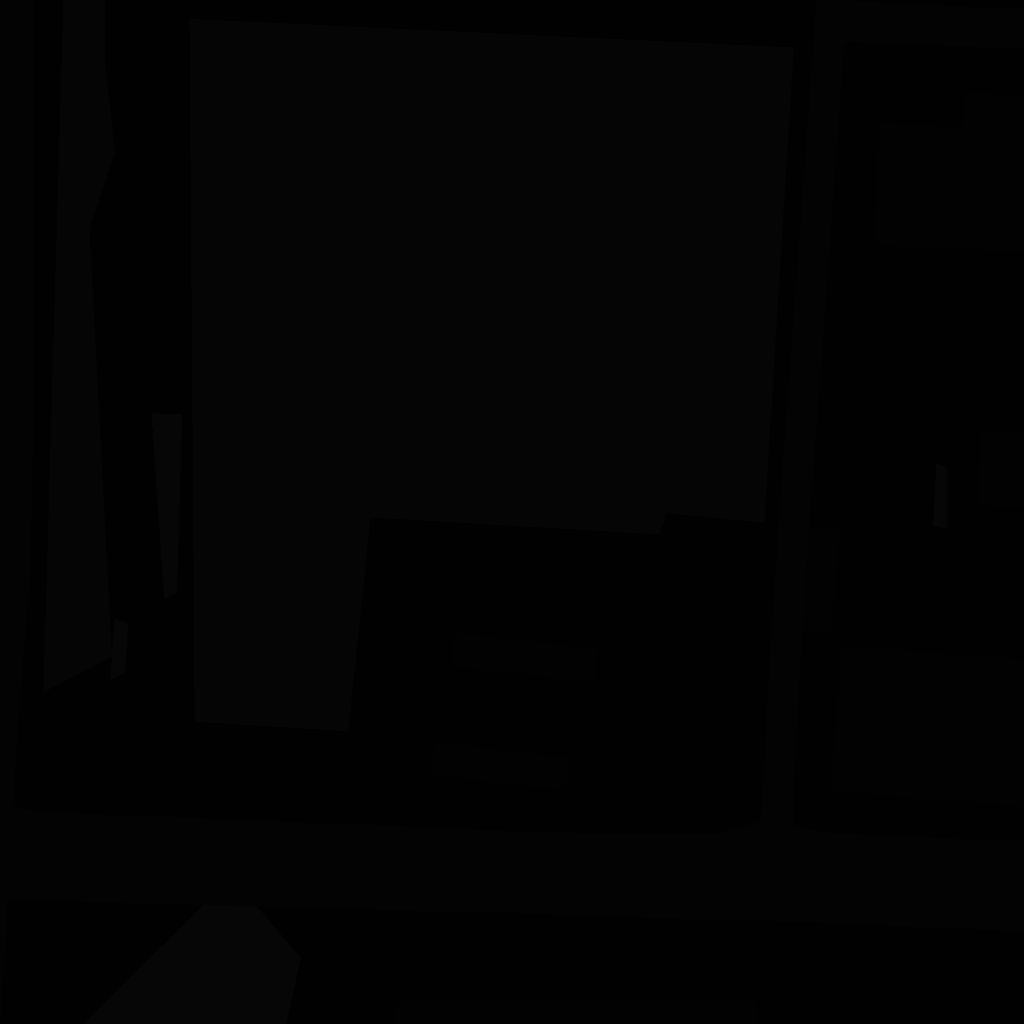

In [13]:
masks_img = Image.open(masked_folder/images[0].name)
masks_img

In [14]:
masks_img = np.array(masks_img)
print("Shape: ",masks_img.shape)
print("DataType: ",masks_img.dtype)
print("minimum: ",masks_img.min())
print("Maximum: ",masks_img.max())
print(np.unique(masks_img))

Shape:  (1024, 1024)
DataType:  uint8
minimum:  1
Maximum:  6
[1 2 3 5 6]


In [16]:
# Class  distribution analysis
from collections import Counter

pixel_counter= Counter()

for mask_paths in masks:
    mask = np.array(Image.open(mask_paths))

    values,counts = np.unique(mask,return_counts=True)

    for v,c in zip(values,counts):
        pixel_counter[int(v)] += int(c)
print(pixel_counter)

Counter({1: 559004254, 2: 244601897, 3: 107065867, 6: 91339922, 5: 87288280, 0: 58395411, 4: 43055087, 7: 21403138})


In [35]:
# ...existing code...
index = list(pixel_counter.keys())
pixel_counter_df = pd.DataFrame.from_dict(pixel_counter, orient='index', columns=['pixel_count'])
pixel_counter_df.index.name = 'class'
pixel_counter_df = pixel_counter_df.sort_index()
print(pixel_counter_df)
# ...existing code...

       pixel_count
class             
0         58395411
1        559004254
2        244601897
3        107065867
4         43055087
5         87288280
6         91339922
7         21403138


<Axes: xlabel='class'>

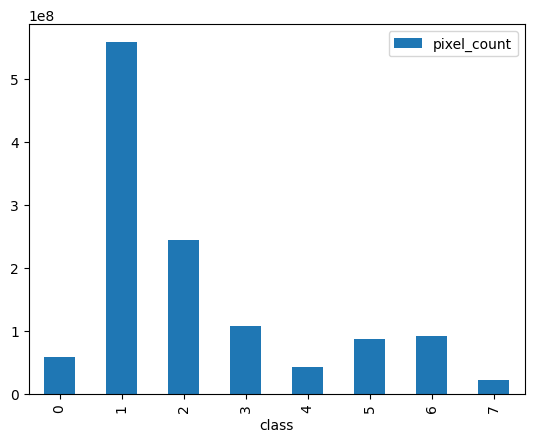

In [38]:
pixel_counter_df.plot(kind='bar')

In [17]:
rural_Train_path = Train_path/"Rural"
for folder in os.listdir(rural_Train_path):
    print(folder)

images_png
masks_png


In [18]:
rural_Train_image_folder = Urban_path/"images_png"
images = list(image_folder.glob('*.png'))
print(len(images))

1156


In [19]:
Test_path = LOVEDA_DIR/"Test"
for folder in os.listdir(Test_path):
    print(folder)

Rural
Urban


In [20]:
Urban_Test_path = Test_path/"Urban"
for folder in os.listdir(Urban_Test_path):
    print(folder)

images_png


In [21]:
Urban_Test_image_folder = Urban_Test_path/"images_png"
images = list(image_folder.glob('*.png'))
print(len(images))

1156
